<a href="https://colab.research.google.com/github/Bhargavi9704047224/Number_plate_detection_yolov8/blob/main/Number_plate_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install gdown  # Ensure gdown is installed

In [ ]:
import gdown

# Replace FILE_ID with your actual file ID
file_id = "114IGrflTQY2E1ygrye22Z3eo9n6mzswC"
output_file = "Number_Plate_Datasets.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=114IGrflTQY2E1ygrye22Z3eo9n6mzswC
From (redirected): https://drive.google.com/uc?id=114IGrflTQY2E1ygrye22Z3eo9n6mzswC&confirm=t&uuid=7c80b10b-4f0a-4487-8bf4-1eb2fa6194c6
To: /content/Number_Plate_Datasets.zip
100%|██████████| 45.3M/45.3M [00:01<00:00, 29.3MB/s]


'Number_Plate_Datasets.zip'

In [ ]:
import zipfile
z = zipfile.ZipFile('/content/Number_Plate_Datasets.zip')
z.extractall()

In [ ]:
import os
import shutil

src = 'Number_Plate_Datasets'
dst_dir = 'datasets'
dst = os.path.join(dst_dir, src)

# Create 'datasets' directory if it doesn't exist
os.makedirs(dst_dir, exist_ok=True)

# If 'pothole_datasets' already exists in 'datasets', remove it
if os.path.exists(dst):
    shutil.rmtree(dst)

# Move 'pothole_datasets' to 'datasets'
shutil.move(src, dst)

print(f"Moved '{src}' to '{dst}' successfully.")


Moved 'Number_Plate_Datasets' to 'datasets/Number_Plate_Datasets' successfully.


## **Importing libraries**

In [ ]:
import yaml

# Define YAML configuration
data = {
    'path': 'Number_Plate_Datasets',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['Plate']
}

# Save to pothole.yaml
with open('Number_Plate_Datasets.yaml', 'w') as file:
    yaml.dump(data, file, default_flow_style=False)

print("Number_Plate_Datasets.yaml created successfully!")


Number_Plate_Datasets.yaml created successfully!


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 model
model = YOLO('yolov8m.pt')  # 'yolov8s.pt' or 'yolov8m.pt' for better accuracy

# Train the model and save only the best checkpoint
model.train(
    data='Number_Plate_Datasets.yaml',
    epochs=3,
    imgsz=640,
    batch=8,
    name='Number_Plate_Datasets_yolov8',
    save=True,
    save_period=-1,  # Don't save every epoch
    patience=20,     # Early stopping if no improvement for 20 epochs (optional)
    val=True     # Run validation during training to select best model
)


Ultralytics 8.4.28 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Number_Plate_Datasets.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Number_Plate_Datasets_yolov82, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7be76d786a80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [27]:
def draw_boxes(image, box, label, color_sample):

    image_with_boxes = image.copy()

    xmin, ymin, xmax, ymax = map(int, box)

    # Ensure correct indexing
    color = random.choice(color_sample)

    # Draw bounding box
    cv2.rectangle(image_with_boxes, (xmin, ymin), (xmax, ymax), color, 2)

    # # Draw label text
    # text = label
    # text_size, _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 2, 4)
    # text_w, text_h = text_size

    # # Adjust text position to prevent out-of-bounds
    # ymin_text = max(ymin - text_h - 5, 0)

    # # Background rectangle for text
    # cv2.rectangle(image_with_boxes, (xmin, ymin_text-5), (xmin + text_w + 10, ymin), color, -1)

    # Put text on the image with white color for better visibility
    cv2.putText(
        image_with_boxes,
        label,
        (xmin, ymax + 25),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        color,
        2,
        cv2.LINE_AA,
    )

    return image_with_boxes


image 1/1 /content/datasets/Number_Plate_Datasets/test/images/42d862ef330cf0ea_jpg.rf.e7c52cdca33450e73a84da5e3288083a.jpg: 640x640 1 Plate, 36.8ms
Speed: 2.1ms preprocess, 36.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.], device='cuda:0')
conf: tensor([0.8142], device='cuda:0')
data: tensor([[ 17.6229,  12.2167, 300.0000, 292.1259,   0.8142,   0.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (300, 300)
shape: torch.Size([1, 6])
xywh: tensor([[158.8114, 152.1713, 282.3771, 279.9092]], device='cuda:0')
xywhn: tensor([[0.5294, 0.5072, 0.9413, 0.9330]], device='cuda:0')
xyxy: tensor([[ 17.6229,  12.2167, 300.0000, 292.1259]], device='cuda:0')
xyxyn: tensor([[0.0587, 0.0407, 1.0000, 0.9738]], device='cuda:0')

image 1/1 /content/datasets/Number_Plate_Datasets/test/images/36296_jpg.rf.bd948ce330b7a83f96518997e1c85758.jpg: 640x640 2 Plates, 34.5ms
Speed: 2.7ms preprocess, 34.5ms 

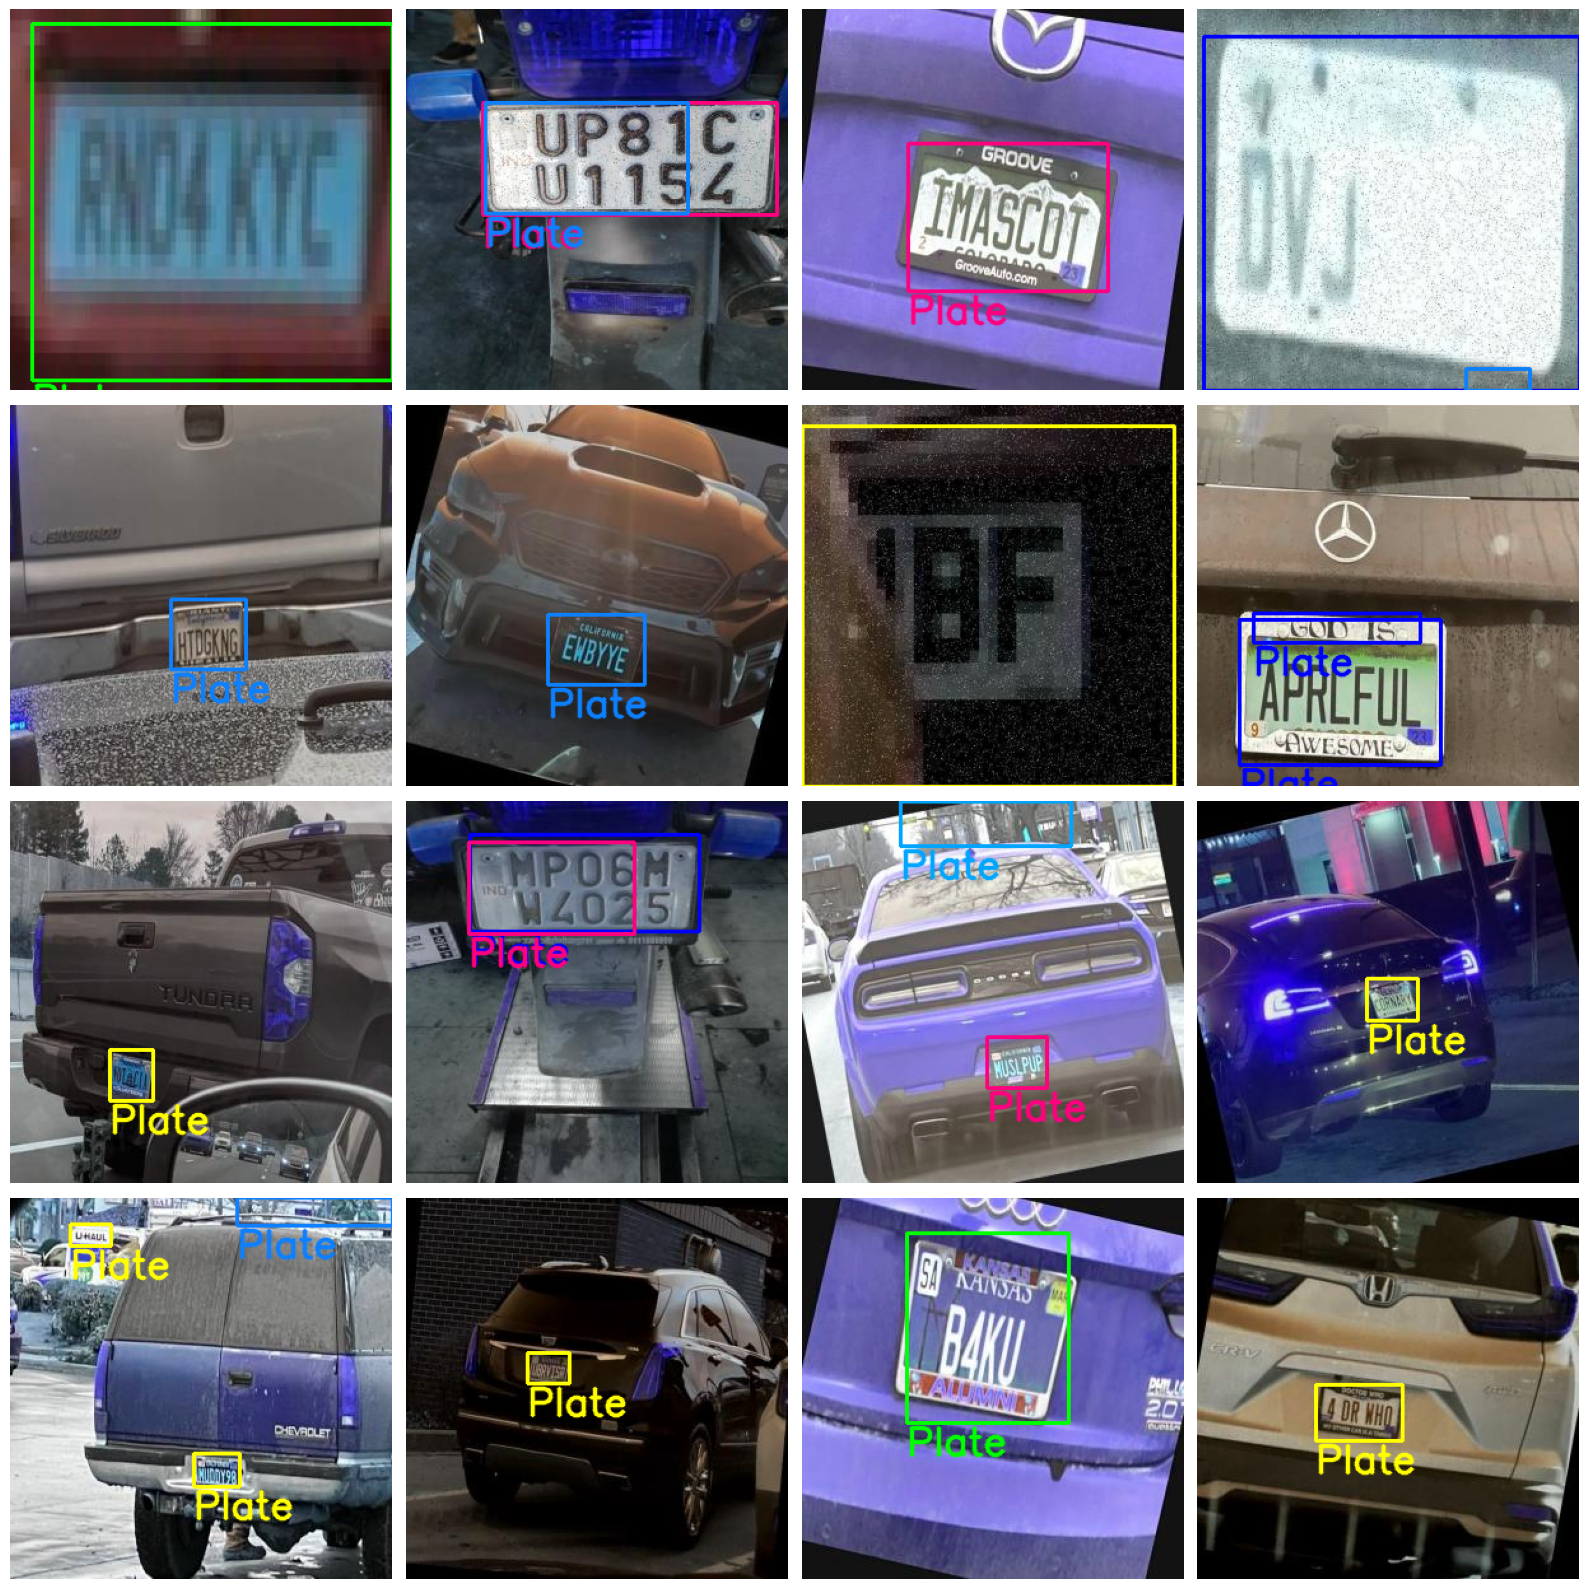

In [31]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
import numpy as np

# Load trained model
model = YOLO("runs/detect/Number_Plate_Datasets_yolov82/weights/best.pt")

# Test images directory
test_images_dir = 'datasets/Number_Plate_Datasets/test/images'

color_sample = [
    (0,0,255),
     (12, 128, 255),   # Orange-ish
     (255, 0, 127),    # Pink
    (0, 255, 0),      # Green
     (255, 255, 0),    # Cyan
     (0, 165, 255)     # Blue-ish
]

# Get list of test images (max 16)
image_files = os.listdir(test_images_dir)

# Plot settings
fig, ax = plt.subplots(4, 4, figsize=(16, 16))
ax = ax.ravel()

for idx in range(16):
    img_name = random.choice(image_files)
    img_path = os.path.join(test_images_dir, img_name)
    image = cv2.imread(img_path)
    #image = image.resize((640,640))
    # image = cv2.imread(img_path)
    # image = cv2.resize(image,(640,640))

    # Inference
    results = model(img_path)[0]
    print(results.boxes)  # Get first result (one image)

    # Draw each box if confidence > 0.8

    for box in results.boxes:

        xyxy = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        image_array = np.array(image)
        image = draw_boxes(image_array, xyxy, label, color_sample)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #image.save(f"img/{idx}.png")

    # Plot
    ax[idx].imshow(image)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()
